## Neural networks

Based on https://docs.pytorch.org/tutorials/beginner/blitz/neural_networks_tutorial.html

See also [Building models with PyTorch on YouTube](https://www.youtube.com/watch?v=OSqIP-mOWOI&list=PL_lsbAsL_o2CTlGHgMxNrKhzP97BaG9ZN&index=4)


Neural networks can be constructed using the `torch.nn` package.

Now that you had a glimpse of autograd, `nn` depends on `autograd` to define models and differentiate them.

An `nn.Module` contains layers, and a method `forward(input)` that returns the output.

For example, look at this network that classifies digit images (based on LeNet):

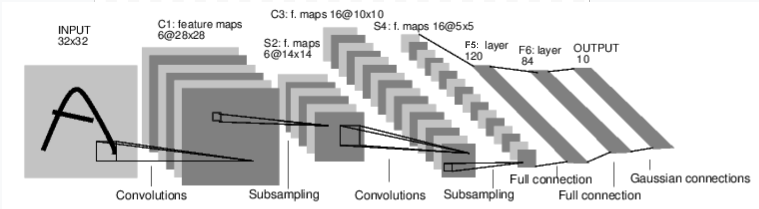


It is a simple feed-forward network. It takes the input, feeds it through several layers one after the other, and then finally gives the output.

A typical training procedure for a neural network is as follows:

- Define the neural network that has some learnable parameters (or weights)
- Iterate over a dataset of inputs
- Process input through the network
- Compute the loss (how far is the output from being correct)
- Propagate gradients back into the network's parameters
- Update the weights of the network, typically using a simple update rule: `weight = weight - learning_rate * gradient`

## Define the network

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [ ]:
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()

        # 1 input image channel, 6 output channels, 5x5 square convolution kernel
        # Convolution layers are used to "extract features" from the source image
        # or from an inner layer.
        # see: https://docs.pytorch.org/docs/stable/generated/torch.nn.Conv2d.html#torch.nn.Conv2d
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=6, kernel_size=5)

        # 6 input channels (from prev layers), 16 output channels, 5x5 square convolution kernel
        self.conv2 = nn.Conv2d(6, 16, 5)
        # an affine operation: y = Wx + b
        self.fc1 = nn.Linear(16 * 5 * 5, 120) # 5*5 from image dimension
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)
    
    def forward(self, input):
        # Convolution layer C1: 1 input image channel, 6 output channels
        # 5x5 square convolution, it uses ReLU activation function,
        # and outputs a Tensor with size (N, 6, 28, 28) where N is the size of the batch
        # Since the convolution has 6 output channels, we can think of it as
        # 6 independent convolution kernels that compute 6 separate output planes from the
        # source image which only has 1 channel (black-and-white?)
        # The output planes have width 28x28 since the input images are 32x32 and we have no padding.
        # Since there's no padding, the convolution kernel will not go out of bounds of the image,
        # i.e. Let's assume the kernel starts its traversal from left to right, top to bottom,
        # then at its left-most top-most point, the kernel's top-left corner will match the top-left
        # corner of the image, meaning the center of the kernel will be at x = kernel_width / 2 and y = kernel_height /2
        # since kernel is 5x5, that means x = 2, y = 2. This means there are 2 rows of pixels top and bottom, i.e. 4 rows in total, which will
        # not be mapped to the output, and 2 columns of pixels, left and right, i.e. 4 cols in total, which will not be mapped to the output
        # And that's how we end up with 32 - 4 = 28 rows and 28 cols of kernel outputs in the a single output channel.

        # The convolution kernel weights (and bias) are parameters that are learned through training
        c1 = F.relu(self.conv1(input))

        # Subsampling layer s2: 2x2 grid, purely functional. Reduces the size of each channel by /2, taking the max value in each 2x2 grid.
        # this layer does not have any parameter, and ouputs a (N, 6, 14, 14) Tensor
        s2 = F.max_pool2d(c1, (2, 2))

        # Convolution layer C3: 6 input channels, 16 output channels,
        # 5x5 square convolution, it uses ReLU activation function,
        # and outputs a (N, 16, 10, 10) Tensor
        c3 = F.relu(self.conv2(s2))

        # Subsampling layer S4: 2x2 grid, purely functional.
        # This layer does not have any parameter, and outputs a (N, 16, 5, 5) Tensor
        s4 = F.max_pool2d(c3, 2)

        # Flatten operation: purely functional, outputs a (N, 400) Tensor
        s4 = torch.flatten(s4, 1)

        # Fully connected layer F5: (N, 400) tensor input,
        # outputs a (N, 120) tensor, it uses ReLU activation function.
        f5 = F.relu(self.fc1(s4))
        
        # Fully connected layer F5: (N, 100) tensor input,
        # outputs (N, 84) tensor, uses ReLU activation
        f6 = F.relu(self.fc2(f5))

        # Fully connected layer output: (N, 84) tensor input,
        # and outputs (N, 10) tensor
        output = self.fc3(f6)
        return output

net = Net()
print(net)

        